In [48]:
import pandas as pd
data = pd.read_csv("bhisma_data.csv")

convergent_cols = [
    "cortisol",
    "cpas",
    "bisq",
    "ses",
    "fci",
    "phq9.score",
    "mors.invasion",
    "mors.warmth",
    "cprs.closeness",
    "cprs.conflict",
    "anthro.waz",
    "anthro.haz",
    "anthro.wfl",
    "anthro.hcz",
    "pmp.daz",
    "maternal.edu",
    "paternal.edu",
    "maternal.muac",
    "rbs.bin.risk",
    "pci.int",
]

data = (
    data.rename(columns={"id": "child_ids"})
    .drop_duplicates(subset="child_ids")
    .assign(
        country=lambda df: df["country"].astype(str),
        child_ids=lambda df: df["child_ids"].astype(str) + "-BL",
    )
    [["child_ids", "country"] + convergent_cols]
)

data.head()


,child_ids,country,cortisol,cpas,bisq,ses,fci,phq9.score,mors.invasion,mors.warmth,...,anthro.waz,anthro.haz,anthro.wfl,anthro.hcz,pmp.daz,maternal.edu,paternal.edu,maternal.muac,rbs.bin.risk,pci.int
0,IN-0003-BL,IN,NaN,0.829047,NaN,-1.100828,0.081612,1.503747,NaN,NaN,...,1.035191,1.846310,-0.275999,0.249022,-0.676677,-1.513419,-1.214618,-1.809783,0.0,NaN
1,IN-0006-BL,IN,NaN,0.431599,NaN,0.689174,0.457766,0.050641,NaN,NaN,...,0.305472,-0.797824,1.221073,-0.811038,-1.801249,0.239936,0.054454,-0.421868,0.0,NaN
2,IN-0007-BL,IN,NaN,0.101850,NaN,-0.745042,1.507111,1.261563,1.776966,0.185820,...,-1.200150,-1.037449,-1.010588,-0.414668,NaN,1.993290,0.054454,-0.678890,0.0,NaN
3,IN-0011-BL,IN,NaN,1.749237,NaN,-0.429187,0.346437,0.535010,NaN,NaN,...,NaN,NaN,NaN,NaN,0.490089,0.239936,-1.214618,-0.267656,0.0,NaN
4,IN-0012-BL,IN,NaN,0.653623,NaN,-0.533899,-2.258632,2.714669,2.333645,-0.338556,...,-0.950752,0.639923,-1.763773,-0.313271,NaN,0.239936,0.054454,0.323493,0.0,NaN


# Convergent Validity: START Age-Adjusted Latent Score

This notebook examines **convergent validity** for the START latent ability score (`start_ability_daz`) — the age-adjusted (GAMLSS-normalised) version of the START IRT–VAE continuous task ability. It tests whether the score is associated with external variables in theoretically expected directions.

## Context

START administers 8 automated tablet tasks to children aged 0–6, yielding 16 continuous performance features. The IRT–VAE uses a linear Gaussian factor decoder to extract a single latent ability `θ`. This is then age-normalised by GAMLSS to remove the chronological age trend, producing `start_ability_daz`.

**Note on sign convention**: The START latent score is negated before analysis (`start["start_ability_daz"] = -start["start_ability_daz"]`) to ensure the sign convention matches the other instruments (higher score = better development).

The convergent variables are grouped into:
- **Expected positive**: attachment security (CPAS), family care (FCI), parent-child closeness (CPRS), SES, maternal/paternal education, maternal nutrition (MUAC), parent-child interaction (PCI), HAZ.
- **Expected negative**: sleep problems (BISQ), maternal depression (PHQ-9), parent-child conflict (CPRS conflict), risk score (RBS).

## Statistical approach

1. **Pearson r** between `start_ability_daz` and each convergent variable.
2. **95% confidence intervals** via Fisher z-transformation.
3. **BH-FDR correction** across all tests.
4. Country-stratified analyses (India, Malawi) and a pooled combined analysis.

See `convergent_analysis_of_GMDS_predicted_using_DEEP.ipynb` for detailed statistical background.

In [49]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# ── Load START & merge ────────────────────────────────────────────────────────
start = pd.read_csv("total_START_old_gamlss_results.csv")
start["start_ability_daz"] = -start["start_ability_daz"]
start = start.drop_duplicates(subset="child_ids").assign(child_ids=lambda df: df["child_ids"].astype(str))
assert start["child_ids"].shape[0] < 4000, "Unexpectedly many rows in START data after deduplication"
start_scores = ["start_ability_daz"]

merged = data.merge(start[["child_ids"] + start_scores], on="child_ids", how="inner")
merged["country_group"] = merged["child_ids"].str[:2]

india  = merged[merged["country_group"] == "IN"].copy()
malawi = merged[merged["country_group"] == "MW"].copy()

print(f"Children after merge:  {len(merged):>4}  total")
print(f"  India  (IN):         {len(india):>4}")
print(f"  Malawi (MW):         {len(malawi):>4}")

# ── Readable labels ───────────────────────────────────────────────────────────
convergent_labels = {
    "cortisol":       "Cortisol",
    "cpas":           "CPAS (Attachment)",
    "bisq":           "BISQ (Sleep)",
    "ses":            "SES",
    "fci":            "FCI (Family Care)",
    "phq9.score":     "PHQ-9 (Dep. Sx)",
    "mors.invasion":  "MORS Invasion",
    "mors.warmth":    "MORS Warmth",
    "cprs.closeness": "CPRS Closeness",
    "cprs.conflict":  "CPRS Conflict",
    "anthro.waz":     "WAZ (Wt-for-age)",
    "anthro.haz":     "HAZ (Ht-for-age)",
    "anthro.wfl":     "WFL (Wt-for-len.)",
    "anthro.hcz":     "HCZ (Head Circumf.)",
    "pmp.daz":        "PMP DAZ",
    "maternal.edu":   "Maternal Education",
    "paternal.edu":   "Paternal Education",
    "maternal.muac":  "Maternal MUAC",
    "rbs.bin.risk":   "RBS Risk",
    "pci.int":        "PCI Interaction",
}

start_labels = {
    "start_ability_daz": "START Ability DAZ",
}

# ── Variable ordering ─────────────────────────────────────────────────────────
anthro_cols = ["anthro.haz"]

pos_convergent_cols = [
    "cpas",           # attachment security → better development
    "fci",            # family care/stimulation → better development
    "cprs.closeness", # parent-child closeness → better development
    "ses",            # socioeconomic resources → better development
    "maternal.edu",   # maternal education → better development
    "paternal.edu",   # paternal education → better development
    "maternal.muac",  # maternal nutrition → better child development
    "pci.int",        # parent-child interaction quality → better development
    "anthro.haz",     # height-for-age → better development
]
neg_convergent_cols = [
    "bisq",           # sleep problems → worse development
    "phq9.score",     # maternal depression → worse development
    "cprs.conflict",  # parent-child conflict → worse development
    "rbs.bin.risk",   # risk score → worse development
]
convergent_cols_ordered = pos_convergent_cols + neg_convergent_cols
N_POS = len(pos_convergent_cols)

# ── BH-FDR correction ────────────────────────────────────────────────────────
def bh_fdr(pvals):
    pvals = np.asarray(pvals, dtype=float)
    out   = np.full_like(pvals, np.nan)
    valid = ~np.isnan(pvals)
    idx   = np.where(valid)[0]
    m     = idx.size
    if m == 0:
        return out
    p_sub  = pvals[idx]
    order  = np.argsort(p_sub)
    ranked = np.empty(m); ranked[order] = np.arange(1, m + 1)
    adj    = p_sub * m / ranked
    adj_sorted = adj[order]
    for i in range(m - 2, -1, -1):
        adj_sorted[i] = min(adj_sorted[i], adj_sorted[i + 1])
    adj[order] = adj_sorted
    out[idx] = np.clip(adj, 0, 1)
    return out

# ── Pearson r + 95% CI (Fisher z) + BH-FDR ──────────────────────────────────
def pearson_table(df, row_vars, col_vars, min_n=8):
    r_mat  = np.full((len(row_vars), len(col_vars)), np.nan)
    p_mat  = np.full((len(row_vars), len(col_vars)), np.nan)
    lo_mat = np.full((len(row_vars), len(col_vars)), np.nan)
    hi_mat = np.full((len(row_vars), len(col_vars)), np.nan)
    n_mat  = np.full((len(row_vars), len(col_vars)), np.nan)
    for i, rv in enumerate(row_vars):
        for j, cv in enumerate(col_vars):
            tmp = df[[rv, cv]].dropna()
            n   = len(tmp)
            n_mat[i, j] = n
            if n >= min_n:
                res = stats.pearsonr(tmp[rv], tmp[cv])
                r_mat[i, j]  = res.statistic
                p_mat[i, j]  = res.pvalue
                ci = res.confidence_interval(confidence_level=0.95)
                lo_mat[i, j] = ci.low
                hi_mat[i, j] = ci.high
    pa_flat = bh_fdr(p_mat.flatten())
    pa_mat  = pa_flat.reshape(p_mat.shape)
    kw = dict(index=row_vars, columns=col_vars)
    return (
        pd.DataFrame(r_mat,  **kw), pd.DataFrame(p_mat,  **kw),
        pd.DataFrame(pa_mat, **kw), pd.DataFrame(lo_mat, **kw),
        pd.DataFrame(hi_mat, **kw), pd.DataFrame(n_mat,  **kw),
    )

# ── Significance stars ────────────────────────────────────────────────────────
def stars(p):
    if pd.isna(p): return ""
    if p < 0.001:  return "***"
    if p < 0.01:   return "**"
    if p < 0.05:   return "*"
    if p < 0.10:   return "·"
    return ""

# ── Formatted table: r* [lo, hi] ─────────────────────────────────────────────
def make_display_table(r_df, pa_df, lo_df, hi_df):
    rows = [convergent_labels.get(r, r) for r in r_df.index]
    cols = [start_labels.get(c, c)       for c in r_df.columns]
    out  = pd.DataFrame(index=rows, columns=cols)
    for i, rv in enumerate(r_df.index):
        for j, cv in enumerate(r_df.columns):
            r  = r_df.iloc[i, j];  p  = pa_df.iloc[i, j]
            lo = lo_df.iloc[i, j]; hi = hi_df.iloc[i, j]
            if np.isnan(r):
                out.iloc[i, j] = "—"
            else:
                out.iloc[i, j] = f"{r:+.2f}{stars(p):3} [{lo:+.2f}, {hi:+.2f}]"
    return out

# ── Heatmap — r, CI, and N shown inside cells ────────────────────────────────
def draw_heatmap(r_df, pa_df, lo_df, hi_df, n_df, title, ax, show_separator=True):
    r_plot = r_df.copy().astype(float)
    r_plot.index   = [convergent_labels.get(r, r) for r in r_df.index]
    r_plot.columns = [start_labels.get(c, c)       for c in r_df.columns]

    annot = pd.DataFrame("", index=r_plot.index, columns=r_plot.columns)
    for i, rv in enumerate(r_df.index):
        for j, cv in enumerate(r_df.columns):
            val   = r_df.iloc[i, j];  p    = pa_df.iloc[i, j]
            lo    = lo_df.iloc[i, j]; hi   = hi_df.iloc[i, j]
            n_val = n_df.iloc[i, j]
            rl = convergent_labels.get(rv, rv)
            cl = start_labels.get(cv, cv)
            if not np.isnan(val):
                s     = stars(p)
                line1 = f"{val:+.2f}{s}"
                line2 = f"[{lo:+.2f},{hi:+.2f}]" if not np.isnan(lo) else ""
                line3 = f"n={int(n_val)}" if not np.isnan(n_val) else ""
                annot.loc[rl, cl] = "\n".join(l for l in [line1, line2, line3] if l)

    sns.heatmap(
        r_plot, ax=ax,
        annot=annot, fmt="",
        center=0, vmin=-1, vmax=1,
        cmap="RdBu_r",
        linewidths=0.5, linecolor="#e0e0e0",
        cbar_kws={"shrink": 0.55, "label": "Pearson r"},
        annot_kws={"size": 10},
    )

    if show_separator:
        n_rows = len(r_df)
        ax.hlines(N_POS, xmin=0, xmax=len(r_df.columns),
                  colors="#111", linewidths=2.5, linestyles="--")
        blend = mtransforms.blended_transform_factory(ax.transAxes, ax.transData)
        # ax.text(-0.01, N_POS / 2.0,
        #         "Expected\n(+)", ha="right", va="center",
        #         fontsize=7.5, color="#444", style="italic",
        #         transform=blend, clip_on=False)
        # ax.text(-0.01, N_POS + (n_rows - N_POS) / 2.0,
        #         "Expected\n(−)", ha="right", va="center",
        #         fontsize=7.5, color="#444", style="italic",
        #         transform=blend, clip_on=False)

    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("START Score", fontsize=10, labelpad=6)
    ax.tick_params(axis="x", rotation=30, labelsize=9)
    ax.tick_params(axis="y", rotation=0,  labelsize=8)


Children after merge:  2342  total
  India  (IN):         1167
  Malawi (MW):         1175


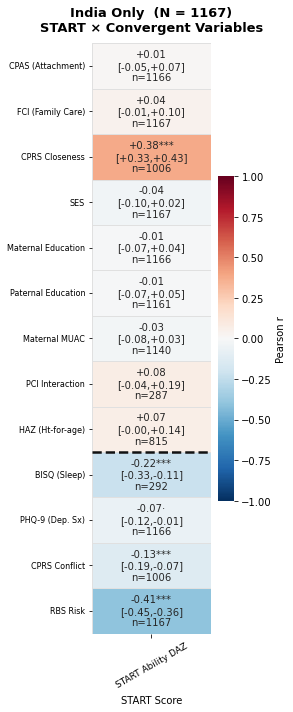


── India: Pearson r  95% CI  (BH-FDR adjusted p)  ·p<.10  *p<.05  **p<.01  ***p<.001 ──



,START Ability DAZ
CPAS (Attachment),"+0.01 [-0.05, +0.07]"
FCI (Family Care),"+0.04 [-0.01, +0.10]"
CPRS Closeness,"+0.38*** [+0.33, +0.43]"
SES,"-0.04 [-0.10, +0.02]"
Maternal Education,"-0.01 [-0.07, +0.04]"
Paternal Education,"-0.01 [-0.07, +0.05]"
Maternal MUAC,"-0.03 [-0.08, +0.03]"
PCI Interaction,"+0.08 [-0.04, +0.19]"
HAZ (Ht-for-age),"+0.07 [-0.00, +0.14]"
BISQ (Sleep),"-0.22*** [-0.33, -0.11]"



────────────────────────────────────────────────────────────
  India — Anthropometric Variables
────────────────────────────────────────────────────────────


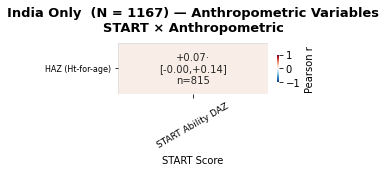


── India (Anthropometric): Pearson r  95% CI  (BH-FDR adjusted p) ──



,START Ability DAZ
HAZ (Ht-for-age),"+0.07· [-0.00, +0.14]"


In [50]:

# ═══════════════════════════════════════════════════════════
#  ANALYSIS 1 — INDIA ONLY
# ═══════════════════════════════════════════════════════════

# ── Main convergent variables ─────────────────────────────
r_in, p_in, pa_in, lo_in, hi_in, n_in = pearson_table(india, convergent_cols_ordered, start_scores)

fig, ax = plt.subplots(figsize=(4, 10))
draw_heatmap(r_in, pa_in, lo_in, hi_in, n_in,
             f"India Only  (N = {len(india)})\nSTART × Convergent Variables", ax)
plt.tight_layout()
plt.savefig("heatmap_start_india.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n── India: Pearson r  95% CI  (BH-FDR adjusted p)  ·p<.10  *p<.05  **p<.01  ***p<.001 ──\n")
display(make_display_table(r_in, pa_in, lo_in, hi_in))

# ── Anthropometric variables (separate analysis) ──────────
print("\n" + "─" * 60)
print("  India — Anthropometric Variables")
print("─" * 60)
r_in_a, p_in_a, pa_in_a, lo_in_a, hi_in_a, n_in_a = pearson_table(india, anthro_cols, start_scores)

fig, ax = plt.subplots(figsize=(4, 2.5))
draw_heatmap(r_in_a, pa_in_a, lo_in_a, hi_in_a, n_in_a,
             f"India Only  (N = {len(india)}) — Anthropometric Variables\nSTART × Anthropometric", ax,
             show_separator=False)
plt.tight_layout()
plt.savefig("heatmap_start_india_anthro.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n── India (Anthropometric): Pearson r  95% CI  (BH-FDR adjusted p) ──\n")
display(make_display_table(r_in_a, pa_in_a, lo_in_a, hi_in_a))


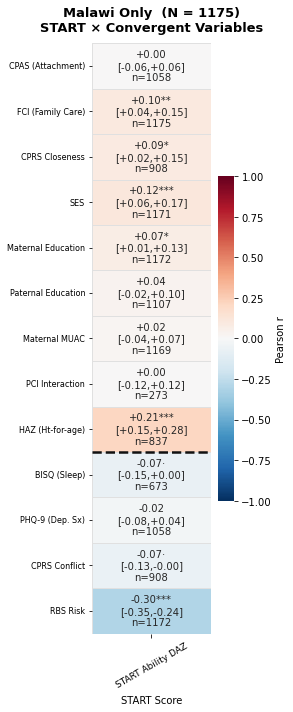


── Malawi: Pearson r  95% CI  (BH-FDR adjusted p)  ·p<.10  *p<.05  **p<.01  ***p<.001 ──



,START Ability DAZ
CPAS (Attachment),"+0.00 [-0.06, +0.06]"
FCI (Family Care),"+0.10** [+0.04, +0.15]"
CPRS Closeness,"+0.09* [+0.02, +0.15]"
SES,"+0.12*** [+0.06, +0.17]"
Maternal Education,"+0.07* [+0.01, +0.13]"
Paternal Education,"+0.04 [-0.02, +0.10]"
Maternal MUAC,"+0.02 [-0.04, +0.07]"
PCI Interaction,"+0.00 [-0.12, +0.12]"
HAZ (Ht-for-age),"+0.21*** [+0.15, +0.28]"
BISQ (Sleep),"-0.07· [-0.15, +0.00]"



────────────────────────────────────────────────────────────
  Malawi — Anthropometric Variables
────────────────────────────────────────────────────────────


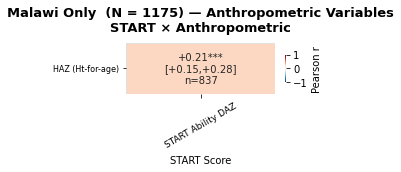


── Malawi (Anthropometric): Pearson r  95% CI  (BH-FDR adjusted p) ──



,START Ability DAZ
HAZ (Ht-for-age),"+0.21*** [+0.15, +0.28]"


In [51]:

# ═══════════════════════════════════════════════════════════
#  ANALYSIS 2 — MALAWI ONLY
# ═══════════════════════════════════════════════════════════

# ── Main convergent variables ─────────────────────────────
r_mw, p_mw, pa_mw, lo_mw, hi_mw, n_mw = pearson_table(malawi, convergent_cols_ordered, start_scores)

fig, ax = plt.subplots(figsize=(4, 10))
draw_heatmap(r_mw, pa_mw, lo_mw, hi_mw, n_mw,
             f"Malawi Only  (N = {len(malawi)})\nSTART × Convergent Variables", ax)
plt.tight_layout()
plt.savefig("heatmap_start_malawi.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n── Malawi: Pearson r  95% CI  (BH-FDR adjusted p)  ·p<.10  *p<.05  **p<.01  ***p<.001 ──\n")
display(make_display_table(r_mw, pa_mw, lo_mw, hi_mw))

# ── Anthropometric variables (separate analysis) ──────────
print("\n" + "─" * 60)
print("  Malawi — Anthropometric Variables")
print("─" * 60)
r_mw_a, p_mw_a, pa_mw_a, lo_mw_a, hi_mw_a, n_mw_a = pearson_table(malawi, anthro_cols, start_scores)

fig, ax = plt.subplots(figsize=(4, 2.5))
draw_heatmap(r_mw_a, pa_mw_a, lo_mw_a, hi_mw_a, n_mw_a,
             f"Malawi Only  (N = {len(malawi)}) — Anthropometric Variables\nSTART × Anthropometric", ax,
             show_separator=False)
plt.tight_layout()
plt.savefig("heatmap_start_malawi_anthro.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n── Malawi (Anthropometric): Pearson r  95% CI  (BH-FDR adjusted p) ──\n")
display(make_display_table(r_mw_a, pa_mw_a, lo_mw_a, hi_mw_a))


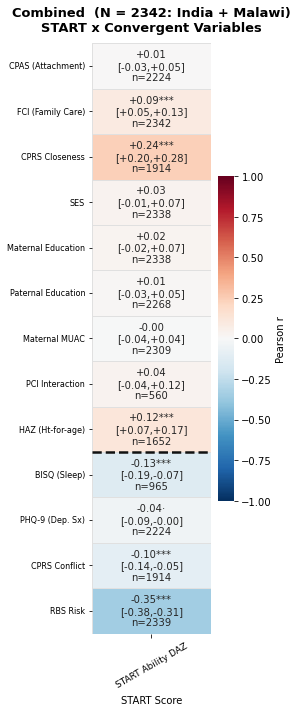


-- Combined: Pearson r  95% CI  (BH-FDR adjusted p)  .p<.10  *p<.05  **p<.01  ***p<.001 --



,START Ability DAZ
CPAS (Attachment),"+0.01 [-0.03, +0.05]"
FCI (Family Care),"+0.09*** [+0.05, +0.13]"
CPRS Closeness,"+0.24*** [+0.20, +0.28]"
SES,"+0.03 [-0.01, +0.07]"
Maternal Education,"+0.02 [-0.02, +0.07]"
Paternal Education,"+0.01 [-0.03, +0.05]"
Maternal MUAC,"-0.00 [-0.04, +0.04]"
PCI Interaction,"+0.04 [-0.04, +0.12]"
HAZ (Ht-for-age),"+0.12*** [+0.07, +0.17]"
BISQ (Sleep),"-0.13*** [-0.19, -0.07]"



------------------------------------------------------------
  Combined - Anthropometric Variables
------------------------------------------------------------


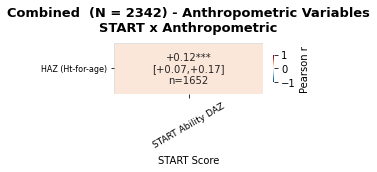


-- Combined (Anthropometric): Pearson r  95% CI  (BH-FDR adjusted p) --



,START Ability DAZ
HAZ (Ht-for-age),"+0.12*** [+0.07, +0.17]"


In [52]:
# ===========================================================
#  ANALYSIS 3 - COMBINED (India + Malawi)
# ===========================================================

# Main convergent variables
r_all, p_all, pa_all, lo_all, hi_all, n_all = pearson_table(merged, convergent_cols_ordered, start_scores)

fig, ax = plt.subplots(figsize=(4, 10))
draw_heatmap(r_all, pa_all, lo_all, hi_all, n_all,
             f"Combined  (N = {len(merged)}: India + Malawi)\nSTART x Convergent Variables", ax)
plt.tight_layout()
plt.savefig("heatmap_start_combined.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n-- Combined: Pearson r  95% CI  (BH-FDR adjusted p)  .p<.10  *p<.05  **p<.01  ***p<.001 --\n")
display(make_display_table(r_all, pa_all, lo_all, hi_all))

# Anthropometric variables (separate analysis)
print("\n" + "-" * 60)
print("  Combined - Anthropometric Variables")
print("-" * 60)
r_all_a, p_all_a, pa_all_a, lo_all_a, hi_all_a, n_all_a = pearson_table(merged, anthro_cols, start_scores)

fig, ax = plt.subplots(figsize=(4, 2.5))
draw_heatmap(r_all_a, pa_all_a, lo_all_a, hi_all_a, n_all_a,
             f"Combined  (N = {len(merged)}) - Anthropometric Variables\nSTART x Anthropometric", ax,
             show_separator=False)
plt.tight_layout()
plt.savefig("heatmap_start_combined_anthro.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n-- Combined (Anthropometric): Pearson r  95% CI  (BH-FDR adjusted p) --\n")
display(make_display_table(r_all_a, pa_all_a, lo_all_a, hi_all_a))


  Convergent Variable Summary  (# START score with p_adj < .05)


,India (sig. START score),Malawi (sig. START score),Combined (sig. START score)
FCI (Family Care),0,1,1
CPRS Closeness,1,1,1
CPRS Conflict,1,0,1
RBS Risk,1,1,1
HAZ (Ht-for-age),0,1,1
BISQ (Sleep),1,0,1
Maternal Education,0,1,0
CPAS (Attachment),0,0,0
SES,0,1,0
PCI Interaction,0,0,0


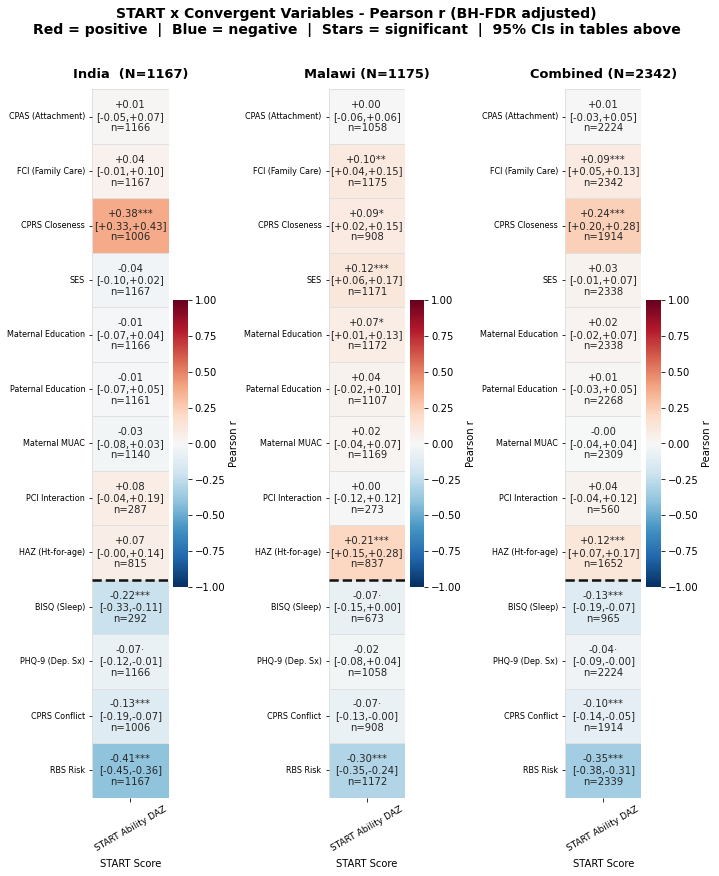

In [53]:
# ===========================================================
#  SUMMARY - significant hits per convergent variable
# ===========================================================

def sig_count(pa_df, threshold=0.05):
    """Count START scores with FDR-adjusted p < threshold."""
    return (pa_df < threshold).sum(axis=1)

summary = pd.DataFrame({
    "India  (sig. START score)"   : sig_count(pa_in),
    "Malawi (sig. START score)"   : sig_count(pa_mw),
    "Combined (sig. START score)" : sig_count(pa_all),
})
summary.index = [convergent_labels.get(r, r) for r in summary.index]
summary = summary.sort_values("Combined (sig. START score)", ascending=False)

print("=" * 65)
print("  Convergent Variable Summary  (# START score with p_adj < .05)")
print("=" * 65)
display(
    summary.style
    .background_gradient(cmap="YlOrRd", axis=None, vmin=0, vmax=1)
    .set_caption("Whether the START ability DAZ score is significantly correlated with each convergent variable (Pearson r, BH-FDR p < .05)")
    .format("{:.0f}")
)

# Side-by-side heatmap overview
fig, axes = plt.subplots(1, 3, figsize=(10, 12))
draw_heatmap(r_in,  pa_in,  lo_in,  hi_in,  n_in,  f"India  (N={len(india)})",    axes[0])
draw_heatmap(r_mw,  pa_mw,  lo_mw,  hi_mw,  n_mw,  f"Malawi (N={len(malawi)})",   axes[1])
draw_heatmap(r_all, pa_all, lo_all, hi_all, n_all, f"Combined (N={len(merged)})", axes[2])
fig.suptitle(
    "START x Convergent Variables - Pearson r (BH-FDR adjusted)\n"
    "Red = positive  |  Blue = negative  |  Stars = significant  |  95% CIs in tables above",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.savefig("heatmap_start_all3.png", dpi=150, bbox_inches="tight")
plt.show()


In [54]:
# ===========================================================
#  EXPORT - save all results to CSV
# ===========================================================

def results_to_long(r_df, p_df, pa_df, lo_df, hi_df, n_df, group):
    rows = []
    for rv in r_df.index:
        for cv in r_df.columns:
            r   = r_df.loc[rv, cv]
            p   = p_df.loc[rv, cv]
            pa  = pa_df.loc[rv, cv]
            lo  = lo_df.loc[rv, cv]
            hi  = hi_df.loc[rv, cv]
            n   = n_df.loc[rv, cv]
            rows.append({
                "group":          group,
                "convergent_var": rv,
                "start_score":     cv,
                "n":              int(n) if not np.isnan(n) else np.nan,
                "r":              round(r,  4) if not np.isnan(r)  else np.nan,
                "ci_low_95":      round(lo, 4) if not np.isnan(lo) else np.nan,
                "ci_high_95":     round(hi, 4) if not np.isnan(hi) else np.nan,
                "p_raw":          round(p,  4) if not np.isnan(p)  else np.nan,
                "p_adj_fdr":      round(pa, 4) if not np.isnan(pa) else np.nan,
                "sig":            stars(pa),
            })
    return pd.DataFrame(rows)

results = pd.concat([
    results_to_long(r_in,  p_in,  pa_in,  lo_in,  hi_in,  n_in,  "India"),
    results_to_long(r_mw,  p_mw,  pa_mw,  lo_mw,  hi_mw,  n_mw,  "Malawi"),
    results_to_long(r_all, p_all, pa_all, lo_all, hi_all, n_all, "Combined"),
], ignore_index=True)

results.to_csv("convergent_correlations_start.csv", index=False)
print(f"Saved {len(results)} rows -> convergent_correlations_start.csv")
print(f"\nColumns: {list(results.columns)}")
display(results.head(10))


Saved 39 rows -> convergent_correlations_start.csv

Columns: ['group', 'convergent_var', 'start_score', 'n', 'r', 'ci_low_95', 'ci_high_95', 'p_raw', 'p_adj_fdr', 'sig']


,group,convergent_var,start_score,n,r,ci_low_95,ci_high_95,p_raw,p_adj_fdr,sig
0,India,cpas,start_ability_daz,1166,0.0081,-0.0493,0.0655,0.7828,0.7828,
1,India,fci,start_ability_daz,1167,0.0427,-0.0147,0.0998,0.1450,0.2692,
2,India,cprs.closeness,start_ability_daz,1006,0.3818,0.3277,0.4334,0.0000,0.0000,***
3,India,ses,start_ability_daz,1167,-0.0388,-0.0959,0.0187,0.1858,0.2818,
4,India,maternal.edu,start_ability_daz,1166,-0.0134,-0.0708,0.0440,0.6474,0.7651,
5,India,paternal.edu,start_ability_daz,1161,-0.0101,-0.0676,0.0475,0.7310,0.7828,
6,India,maternal.muac,start_ability_daz,1140,-0.0268,-0.0848,0.0313,0.3655,0.4752,
7,India,pci.int,start_ability_daz,287,0.0767,-0.0394,0.1908,0.1951,0.2818,
8,India,anthro.haz,start_ability_daz,815,0.0670,-0.0017,0.1351,0.0558,0.1209,
9,India,bisq,start_ability_daz,292,-0.2229,-0.3292,-0.1109,0.0001,0.0004,***
